# Compare YOLO26-seg Fine-tuning: color spaces (RGB · LAB · HED) — v7

Notebook unificado para comparar fine-tuning do **YOLO26-seg** no
**ISIC 2018 Task 1** quando os dados são alimentados em **diferentes
representações de cor**:

- **RGB** — baseline original do dataset.
- **LAB** — luminância (L) separada da cromaticidade (a, b). Pode ajudar
  a generalizar sob variação de iluminação típica de dermatoscopia.
- **HED** — decomposição Hematoxylin-Eosin-DAB (Ruifrok-Johnston).
  Originalmente desenhada para slides histopatológicos H&E, aqui é usada
  como uma transformação determinística adicional que descorrelaciona
  os canais — vale comparar.

**RGB é tratada como baseline** em todas as comparações de Δ.

## Conteúdo

1. **Setup** — paths, paleta categórica acessível, helpers
2. **Carga de dados** — `results.csv` + `args.yaml` por (color_space, modelo)
3. **Resumo executivo** — tabela ranqueada + champion por modelo + Δ vs RGB
4. **Performance principal** — Mask/BBox mAP, Y cropado para a região de sinal
5. **Métricas operacionais** — P/R/loss/tempo
6. **Δ vs RGB** — uma tabela e um heatmap por color space não-RGB
7. **Robustez geométrica** — `mAP@50-95 / mAP@50`
8. **Estabilidade** — std de `mAP@50-95(M)` nas últimas 10 épocas
9. **Convergência** — épocas até 95% / 99% do best
10. **Curvas de treino** — `mAP@50-95(M)` suavizado, hue=color space
11. **Curvas de loss** — `train` vs `val seg_loss` + overfit gap
12. **LR efetivo** — `lr/pg0` médio (mid)
13. **Pareto** — `mAP × tempo de treino`
14. **Hiperparâmetros** — diff entre color spaces (esperado: tudo igual,
    a única variável é o color_space upstream)
15. **Conclusões** — destaques automáticos

## Decisões de visualização

- **Paleta** (Okabe-Ito): `RGB = azul` (#0072B2), `LAB = laranja` (#E69F00),
  `HED = verde` (#009E73). Alto contraste, colorblind-safe.
- **Y-axis cropado**: faixa de mAP é tipicamente 0.60-0.99; cropar deixa
  diferenças de 1-3 pts visíveis.
- **Legendas fora dos eixos** (`bbox_to_anchor`) para não cobrir dados.

## Como adicionar mais modelos / color spaces

Edite `VERSIONS[<color_space>]["model_dirs"]` para incluir Nano, Medium,
Large e/ou XLarge. Para adicionar um novo color space, basta criar uma
nova chave em `VERSIONS` e em `VERSION_PALETTE` — todas as seções
auto-adaptam.


## 1. Setup

In [71]:
import warnings
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display, Markdown
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)

# ----- estilo global ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
})
sns.set_context("notebook", font_scale=1.0)

# ----- paleta color spaces (Okabe-Ito subset) -------------------------------
VERSION_PALETTE = {
    "RGB": "#0072B2",  # blue       (baseline)
    "LAB": "#E69F00",  # orange
    "HED": "#009E73",  # green
}
# Color space tratado como baseline em todas as comparações de Δ.
BASELINE = "RGB"
SUCCESS = "#2A9D8F"
DANGER = "#E63946"
NEUTRAL = "#6C757D"

print("Setup OK — palette:", list(VERSION_PALETTE))


Setup OK — palette: ['RGB', 'LAB', 'HED']


### 1.1 Path configuration

In [72]:
# Mude `unb_server` conforme o ambiente.
unb_server = True

if unb_server:
    BASE_DIR = Path("/home/antoniovinicius/projects/sandbox_yolo26")
else:
    BASE_DIR = Path("/home/avmoura_linux/Documents/unb/sandbox_yolo26")

# Convenção: para cada color_space, mapeia Modelo -> nome de pasta dentro de
# BASE_DIR/logs/. Adicione/remova entries para incluir mais modelos.
VERSIONS = {
    "RGB": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v7",
        "model_dirs": {
            # "Nano":   "yolo26_nano_ft_isic_2018_v7",
            "Small":   "yolo26_small_ft_isic_2018_v7",
            # "Medium": "yolo26_medium_ft_isic_2018_v7",
            # "Large":  "yolo26_large_ft_isic_2018_v7",
            # "XLarge": "yolo26_xlarge_ft_isic_2018_v7",
        },
    },
    "LAB": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v7",
        "model_dirs": {
            # "Nano":   "yolo26_nano_ft_isic_2018_v7_lab",
            "Small":   "yolo26_small_ft_isic_2018_v7_lab",
            # "Medium": "yolo26_medium_ft_isic_2018_v7_lab",
            # "Large":  "yolo26_large_ft_isic_2018_v7_lab",
            # "XLarge": "yolo26_xlarge_ft_isic_2018_v7_lab",
        },
    },
    "HED": {
        "log_dir": BASE_DIR / "logs" / "train_isic_2018_task_1_v7",
        "model_dirs": {
            # "Nano":   "yolo26_nano_ft_isic_2018_v7_hed",
            "Small":   "yolo26_small_ft_isic_2018_v7_hed",
            # "Medium": "yolo26_medium_ft_isic_2018_v7_hed",
            # "Large":  "yolo26_large_ft_isic_2018_v7_hed",
            # "XLarge": "yolo26_xlarge_ft_isic_2018_v7_hed",
        },
    },
}

# Ordem ampla — modelos não presentes serão ignorados silenciosamente.
MODEL_ORDER = ["Nano", "Small", "Medium", "Large", "XLarge"]
VERSION_ORDER = list(VERSIONS.keys())

# Confere existência de cada run
print("Conferindo runs existentes:")
for v, cfg in VERSIONS.items():
    for m, d in cfg["model_dirs"].items():
        p = cfg["log_dir"] / d
        ok = "ok" if p.exists() else "MISSING"
        print(f"  [{ok:>7}] {v}/{m}: {p}")

print(f"\nColor spaces: {VERSION_ORDER}  |  Modelos definidos: ", end="")
print(sorted({m for cfg in VERSIONS.values() for m in cfg["model_dirs"]}))


Conferindo runs existentes:
  [     ok] RGB/Small: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_small_ft_isic_2018_v7
  [     ok] LAB/Small: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_small_ft_isic_2018_v7_lab
  [     ok] HED/Small: /home/antoniovinicius/projects/sandbox_yolo26/logs/train_isic_2018_task_1_v7/yolo26_small_ft_isic_2018_v7_hed

Color spaces: ['RGB', 'LAB', 'HED']  |  Modelos definidos: ['Small']


## 2. Helpers

In [73]:
def smooth(x: np.ndarray, window: int = 5) -> np.ndarray:
    """Centered moving average (NaN-safe)."""
    s = pd.Series(x).rolling(window=window, center=True, min_periods=1).mean()
    return s.to_numpy()


def add_value_labels(ax, fmt: str = "{:.3f}", padding: float = 0.005, fontsize: int = 9) -> None:
    """Annotate bars with their height. Padding is proportional to ymax-ymin."""
    ymin, ymax = ax.get_ylim()
    pad = (ymax - ymin) * padding
    for p in ax.patches:
        h = p.get_height()
        if not np.isfinite(h):
            continue
        ax.annotate(
            fmt.format(h),
            (p.get_x() + p.get_width() / 2.0, h + pad),
            ha="center", va="bottom", fontsize=fontsize, color="#333",
        )


def epochs_to_threshold(df: pd.DataFrame, col: str, frac: float = 0.95) -> int | float:
    """First epoch where col >= frac * max(col)."""
    if col not in df or df[col].dropna().empty:
        return np.nan
    target = df[col].max() * frac
    hit = df.loc[df[col] >= target, "epoch"]
    if hit.empty:
        return np.nan
    return int(hit.iloc[0])


def stability(df: pd.DataFrame, col: str, last_n: int = 10) -> float:
    """Std of the last N epochs (lower = more stable)."""
    if col not in df:
        return np.nan
    s = df[col].dropna().tail(last_n)
    return float(s.std()) if not s.empty else np.nan


def overfit_gap(df: pd.DataFrame, best_idx: int, train_col: str, val_col: str) -> float:
    """val-train at best epoch (positive = overfit)."""
    try:
        return float(df.loc[best_idx, val_col] - df.loc[best_idx, train_col])
    except (KeyError, IndexError):
        return np.nan


print("Helpers ready")


Helpers ready


## 3. Carga de dados (`results.csv` + `args.yaml`)

In [74]:
def extract_summary(version: str, model_name: str, results_dir: Path) -> dict | None:
    """Extract all summary metrics from a single training run."""
    rcsv = results_dir / "results.csv"
    if not rcsv.exists():
        return None
    df = pd.read_csv(rcsv)
    df.columns = [c.strip() for c in df.columns]

    if "metrics/mAP50-95(M)" not in df:
        return None

    best_idx = df["metrics/mAP50-95(M)"].idxmax()
    best = df.loc[best_idx]

    args_path = results_dir / "args.yaml"
    args = {}
    if args_path.exists():
        try:
            args = yaml.safe_load(args_path.read_text()) or {}
        except yaml.YAMLError:
            args = {}

    if "lr/pg0" in df:
        lr = df["lr/pg0"]
        n = len(lr)
        lr_start = float(lr.iloc[: max(1, n // 10)].mean())
        lr_mid = float(lr.iloc[n // 3: 2 * n // 3].mean())
        lr_end = float(lr.iloc[-max(1, n // 10):].mean())
    else:
        lr_start = lr_mid = lr_end = np.nan

    return {
        "Version": version,
        "Model": model_name,
        "Run dir": results_dir.name,
        # best metrics
        "Mask mAP@50": float(best.get("metrics/mAP50(M)", np.nan)),
        "Mask mAP@50-95": float(best.get("metrics/mAP50-95(M)", np.nan)),
        "BBox mAP@50": float(best.get("metrics/mAP50(B)", np.nan)),
        "BBox mAP@50-95": float(best.get("metrics/mAP50-95(B)", np.nan)),
        "Mask Precision": float(best.get("metrics/precision(M)", np.nan)),
        "Mask Recall": float(best.get("metrics/recall(M)", np.nan)),
        # losses
        "Val seg_loss": float(best.get("val/seg_loss", np.nan)),
        "Train seg_loss": float(best.get("train/seg_loss", np.nan)),
        "Overfit gap (seg)": overfit_gap(df, best_idx, "train/seg_loss", "val/seg_loss"),
        # training dynamics
        "Best epoch": int(best.get("epoch", best_idx)),
        "Total epochs": int(df["epoch"].max()),
        "Train time (min)": float(df["time"].iloc[-1] / 60.0) if "time" in df else np.nan,
        # convergence + stability
        "Eps to 95% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.95),
        "Eps to 99% best": epochs_to_threshold(df, "metrics/mAP50-95(M)", 0.99),
        "Stability (std last10)": stability(df, "metrics/mAP50-95(M)", last_n=10),
        # LR effective
        "lr/pg0 start": lr_start,
        "lr/pg0 mid": lr_mid,
        "lr/pg0 end": lr_end,
        # hyperparameters of interest
        "optimizer": args.get("optimizer", "?"),
        "lr0": args.get("lr0", np.nan),
        "amp": args.get("amp", "?"),
        "batch": args.get("batch", "?"),
        "epochs (cfg)": args.get("epochs", "?"),
        "close_mosaic": args.get("close_mosaic", "?"),
        "erasing": args.get("erasing", "?"),
        "weight_decay": args.get("weight_decay", "?"),
        "dropout": args.get("dropout", "?"),
        # full df for curves
        "_df": df,
    }


rows = []
for v in VERSION_ORDER:
    cfg = VERSIONS[v]
    for m in MODEL_ORDER:
        dir_name = cfg["model_dirs"].get(m)
        if dir_name is None:
            continue
        d = cfg["log_dir"] / dir_name
        s = extract_summary(v, m, d)
        if s is None:
            print(f"  [skip] {v}/{m} (no results.csv at {d})")
            continue
        rows.append(s)

df_long = pd.DataFrame(rows)
if df_long.empty:
    raise RuntimeError("Nenhum run encontrado — verifique os paths em VERSIONS")

# Reduz MODEL_ORDER aos modelos efetivamente carregados, preservando ordem
present_models = [m for m in MODEL_ORDER if m in df_long["Model"].unique()]
df_long["Version"] = pd.Categorical(df_long["Version"], categories=VERSION_ORDER, ordered=True)
df_long["Model"] = pd.Categorical(df_long["Model"], categories=present_models, ordered=True)
df_long = df_long.sort_values(["Model", "Version"]).reset_index(drop=True)
MODEL_ORDER_PRESENT = present_models

print(f"Loaded {len(df_long)} runs across {df_long['Version'].nunique()} color spaces × {df_long['Model'].nunique()} models")
display(df_long.drop(columns=["_df"]).head(10))


Loaded 3 runs across 3 color spaces × 1 models


,Version,Model,Run dir,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Val seg_loss,...,lr/pg0 end,optimizer,lr0,amp,batch,epochs (cfg),close_mosaic,erasing,weight_decay,dropout
0,RGB,Small,yolo26_small_ft_isic_2018_v7,0.95760,0.69640,0.97281,0.67234,0.94925,0.93527,1.57601,...,0.005237,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
1,LAB,Small,yolo26_small_ft_isic_2018_v7_lab,0.96390,0.69722,0.94359,0.67174,0.95587,0.92000,1.64787,...,0.005184,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0
2,HED,Small,yolo26_small_ft_isic_2018_v7_hed,0.94854,0.67302,0.94854,0.64361,0.93954,0.86000,1.54730,...,0.005263,MuSGD,0.002,True,32,120,15,0.0,0.0005,0.0


## 4. Resumo executivo

Tabela com `Mask mAP@50-95` por modelo × color space, com **champion**
marcado por linha. Responde direto: qual color space rende mais por
modelo. Em seguida, uma tabela Δ vs RGB para cada color space não-RGB.


In [75]:
pivot_main = df_long.pivot(index="Model", columns="Version", values="Mask mAP@50-95")
pivot_main = pivot_main[VERSION_ORDER].reindex(MODEL_ORDER_PRESENT)


def highlight_max_row(s: pd.Series):
    is_max = s == s.max()
    return [
        f"background-color: {SUCCESS}; color: white; font-weight: 600" if v else ""
        for v in is_max
    ]


display(Markdown("### 4.1 Champion por modelo (Mask mAP@50-95)"))
display(
    pivot_main.style
    .apply(highlight_max_row, axis=1)
    .format("{:.4f}", na_rep="—")
    .set_caption("Verde = melhor color space para o modelo")
)

# Δ vs RGB (positivo = color space ganha do RGB) — uma tabela por color space não-baseline
if BASELINE in pivot_main.columns:
    others = [v for v in VERSION_ORDER if v != BASELINE and v in pivot_main.columns]
    if others:
        display(Markdown(f"### 4.2 Δ vs {BASELINE} (positivo = color space melhor que {BASELINE})"))
    for v in others:
        delta = (pivot_main[v] - pivot_main[BASELINE]).rename(f"Δ ({v} − {BASELINE})")
        delta_table = pd.DataFrame({
            "Model":             delta.index,
            BASELINE:            pivot_main[BASELINE].values,
            v:                   pivot_main[v].values,
            f"Δ ({v} − {BASELINE})": delta.values,
            "% relative":        (delta / pivot_main[BASELINE]).values * 100,
        })
        display(Markdown(f"**{v} vs {BASELINE}**"))
        display(delta_table.style.format({
            BASELINE:            "{:.4f}",
            v:                   "{:.4f}",
            f"Δ ({v} − {BASELINE})": "{:+.4f}",
            "% relative":        "{:+.2f}%",
        }).background_gradient(subset=[f"Δ ({v} − {BASELINE})"], cmap="RdYlGn", vmin=-0.05, vmax=0.05))


### 4.1 Champion por modelo (Mask mAP@50-95)

Version,RGB,LAB,HED
Model,,,
Small,0.6964,0.6972,0.6730


### 4.2 Δ vs RGB (positivo = color space melhor que RGB)

**LAB vs RGB**

,Model,RGB,LAB,Δ (LAB − RGB),% relative
0,Small,0.6964,0.6972,+0.0008,+0.12%


**HED vs RGB**

,Model,RGB,HED,Δ (HED − RGB),% relative
0,Small,0.6964,0.6730,-0.0234,-3.36%


## 5. Performance principal

Barras agrupadas por modelo (eixo-x), uma cor por color space.
Y-axis **cropado** para a faixa de sinal — diferenças ficam visíveis.


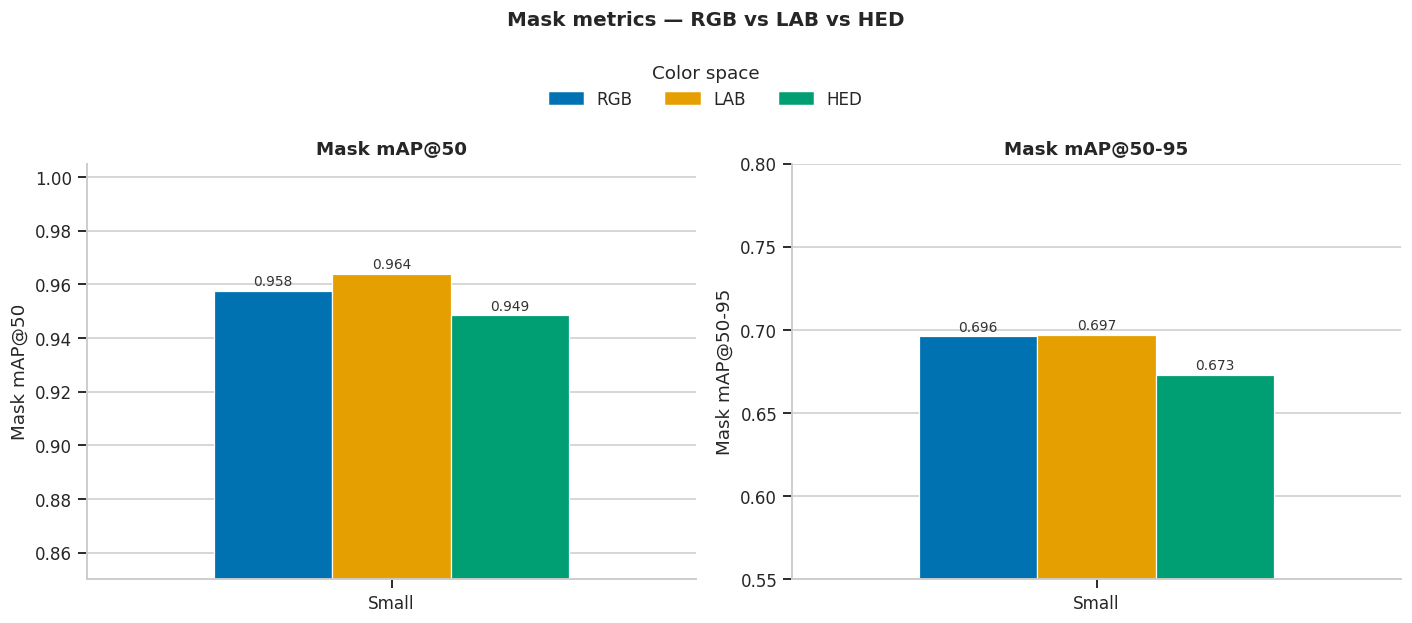

In [76]:
def grouped_bar(ax, data: pd.DataFrame, value_col: str, title: str,
                ylim: tuple[float, float] | None = None, fmt: str = "{:.3f}",
                models: list[str] | None = None) -> None:
    models = models or MODEL_ORDER_PRESENT
    pivot = data.pivot(index="Model", columns="Version", values=value_col)[VERSION_ORDER].reindex(models)
    pivot.plot(
        kind="bar", ax=ax, width=0.7,
        color=[VERSION_PALETTE[v] for v in VERSION_ORDER],
        edgecolor="white", linewidth=0.8,
    )
    ax.set_title(title)
    ax.set_ylabel(value_col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    if ylim:
        ax.set_ylim(*ylim)
    add_value_labels(ax, fmt=fmt)
    ax.grid(axis="x", visible=False)


# ---- Mask -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
grouped_bar(axes[0], df_long, "Mask mAP@50",    "Mask mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], df_long, "Mask mAP@50-95", "Mask mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Color space", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSION_ORDER))
fig.suptitle("Mask metrics — " + " vs ".join(VERSION_ORDER), y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


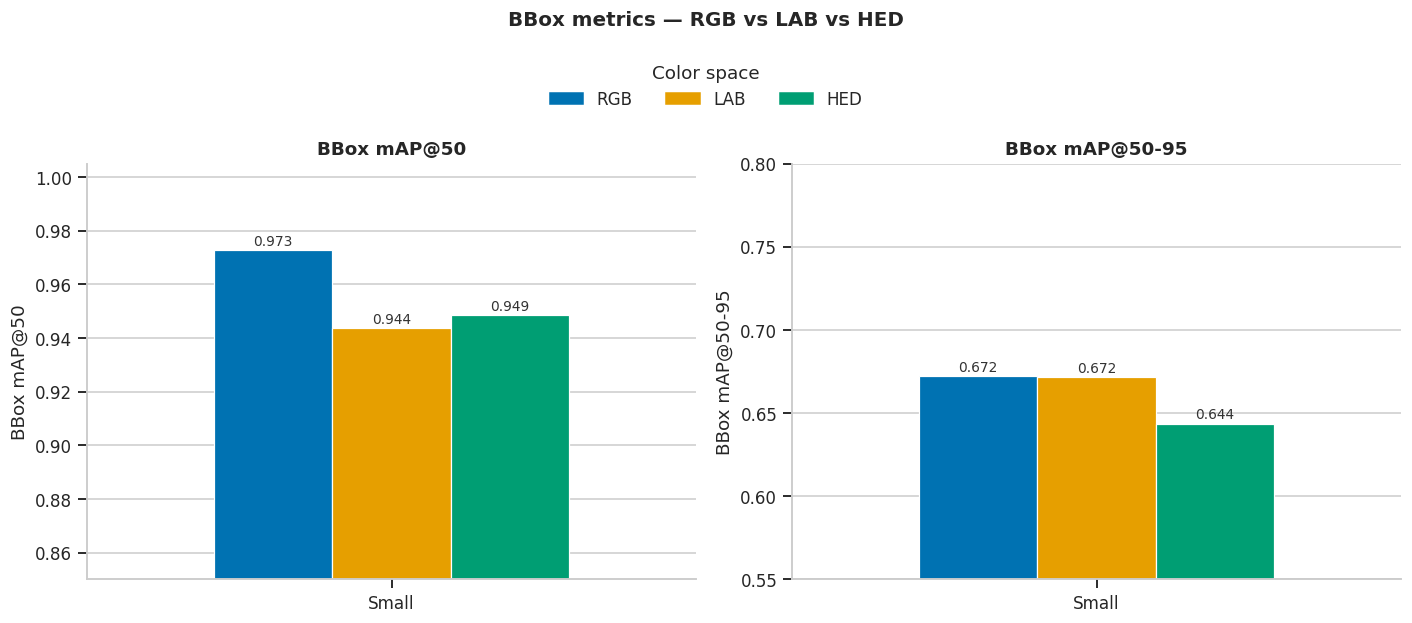

In [77]:
# ---- BBox -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
grouped_bar(axes[0], df_long, "BBox mAP@50",    "BBox mAP@50",    ylim=(0.85, 1.005))
grouped_bar(axes[1], df_long, "BBox mAP@50-95", "BBox mAP@50-95", ylim=(0.55, 0.80))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Color space", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSION_ORDER))
fig.suptitle("BBox metrics — " + " vs ".join(VERSION_ORDER), y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Métricas operacionais

P/R, perda em validação no best epoch e tempo total de treino.

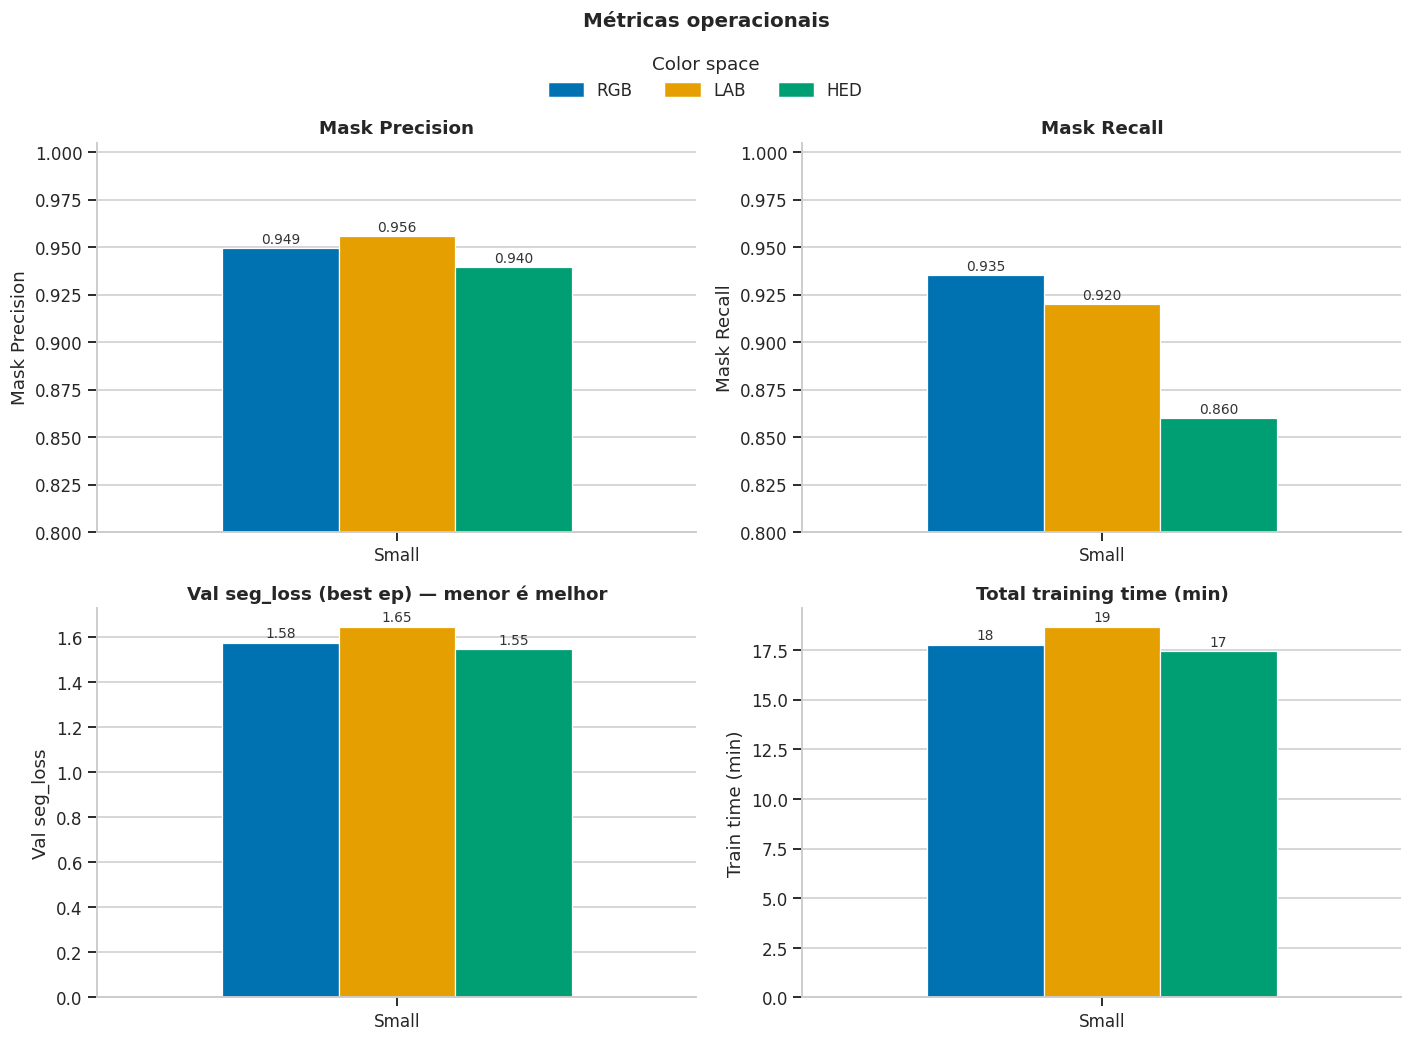

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
grouped_bar(axes[0, 0], df_long, "Mask Precision", "Mask Precision", ylim=(0.80, 1.005))
grouped_bar(axes[0, 1], df_long, "Mask Recall",    "Mask Recall",    ylim=(0.80, 1.005))
grouped_bar(axes[1, 0], df_long, "Val seg_loss",   "Val seg_loss (best ep) — menor é melhor", fmt="{:.2f}")
grouped_bar(axes[1, 1], df_long, "Train time (min)", "Total training time (min)", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Color space", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=len(VERSION_ORDER))
fig.suptitle("Métricas operacionais", y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Δ vs RGB por métrica

Um heatmap divergente por color space não-baseline. **Verde** = color
space melhor que RGB para a métrica/modelo, **vermelho** = RGB melhor.
Para métricas onde "menor é melhor" (loss, tempo, overfit gap, std,
épocas até best) o sinal é invertido para manter a convenção
"verde = color space favorecido".


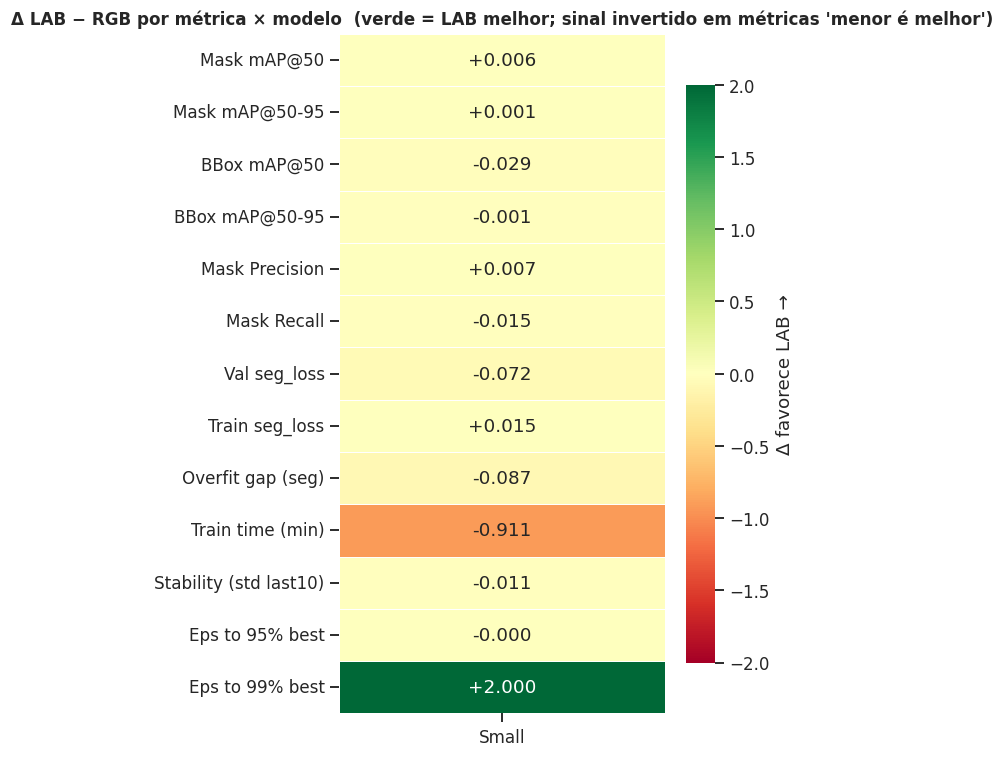

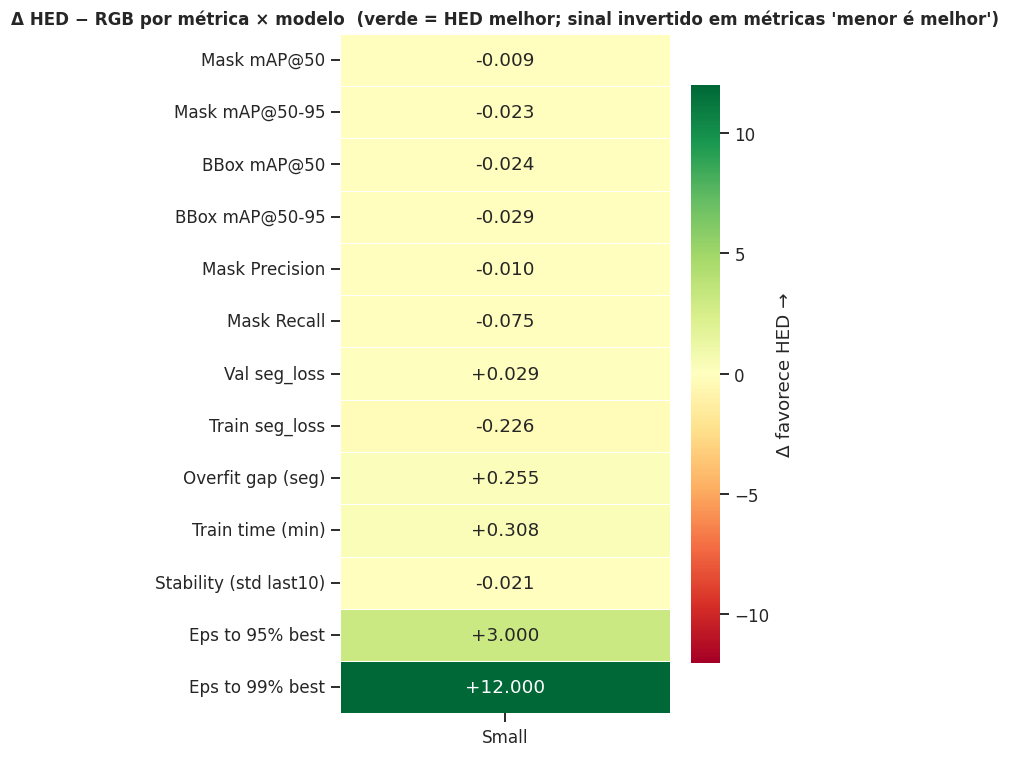

In [79]:
higher_better = [
    "Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
    "Mask Precision", "Mask Recall",
]
lower_better = [
    "Val seg_loss", "Train seg_loss", "Overfit gap (seg)",
    "Train time (min)", "Stability (std last10)",
    "Eps to 95% best", "Eps to 99% best",
]

versions_loaded = list(df_long["Version"].unique())
others = [v for v in VERSION_ORDER if v != BASELINE and v in versions_loaded]

if BASELINE not in versions_loaded or not others:
    print(f"Heatmap requer {BASELINE} + pelo menos um outro color space simultaneamente.")
else:
    for v in others:
        rows_delta = []
        for met in higher_better + lower_better:
            for m in MODEL_ORDER_PRESENT:
                sel = df_long[df_long["Model"] == m]
                base_v = sel[sel["Version"] == BASELINE][met]
                cur_v  = sel[sel["Version"] == v][met]
                if base_v.empty or cur_v.empty:
                    continue
                d = float(cur_v.iloc[0]) - float(base_v.iloc[0])
                if met in lower_better:
                    d = -d  # convenção: positivo = color space favorecido
                rows_delta.append({"Metric": met, "Model": m, f"Δ ({v} favors)": d})
        delta_df = pd.DataFrame(rows_delta)
        if delta_df.empty:
            print(f"  [skip] sem dados para Δ {v} − {BASELINE}")
            continue
        delta_pivot = delta_df.pivot(index="Metric", columns="Model", values=f"Δ ({v} favors)")
        delta_pivot = delta_pivot.reindex(higher_better + lower_better).reindex(columns=MODEL_ORDER_PRESENT)

        vmax = max(abs(delta_pivot.min().min()), abs(delta_pivot.max().max())) or 0.001
        fig, ax = plt.subplots(figsize=(max(6, 1.6 * len(MODEL_ORDER_PRESENT)), 0.45 * len(delta_pivot) + 1.2))
        sns.heatmap(
            delta_pivot, annot=True, fmt="+.3f",
            cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
            cbar_kws={"label": f"Δ favorece {v} →", "shrink": 0.85},
            linewidths=0.5, linecolor="white", ax=ax,
        )
        ax.set_title(
            f"Δ {v} − {BASELINE} por métrica × modelo  "
            f"(verde = {v} melhor; sinal invertido em métricas 'menor é melhor')",
            fontsize=11,
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()


## 8. Robustez geométrica — `mAP@50-95 / mAP@50`

`mAP@50` aceita IoU ≥ 0.5 (boa localização aproximada). `mAP@50-95` requer
IoU alto consistentemente. **A razão mede o quanto a borda da máscara
'sobrevive' ao critério rigoroso** — proxy direto de qualidade da
segmentação fina.


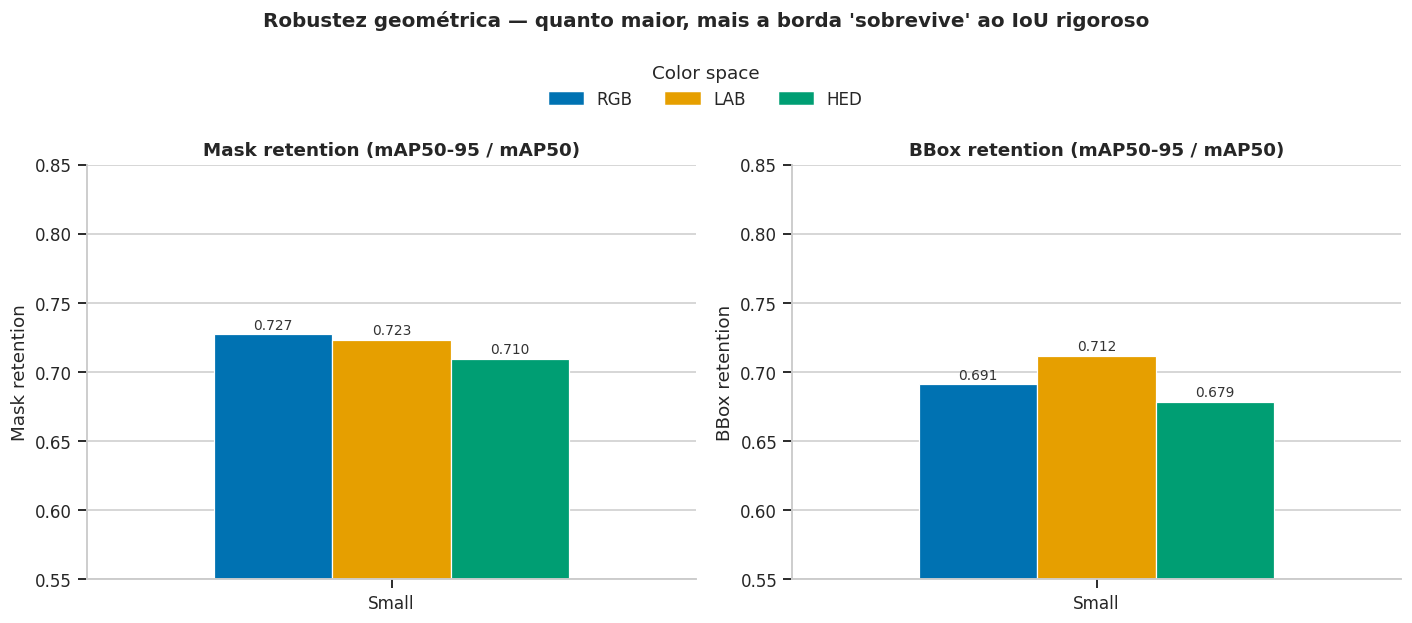

In [80]:
df_long["Mask retention"] = df_long["Mask mAP@50-95"] / df_long["Mask mAP@50"]
df_long["BBox retention"] = df_long["BBox mAP@50-95"] / df_long["BBox mAP@50"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
grouped_bar(axes[0], df_long, "Mask retention", "Mask retention (mAP50-95 / mAP50)", ylim=(0.55, 0.85))
grouped_bar(axes[1], df_long, "BBox retention", "BBox retention (mAP50-95 / mAP50)", ylim=(0.55, 0.85))

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Color space", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSION_ORDER))
fig.suptitle("Robustez geométrica — quanto maior, mais a borda 'sobrevive' ao IoU rigoroso",
             y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Estabilidade do treino

Std de `mAP@50-95(M)` nas **últimas 10 épocas**. Valor baixo = treino
convergiu; alto = ainda oscila (best pode ser sorte).


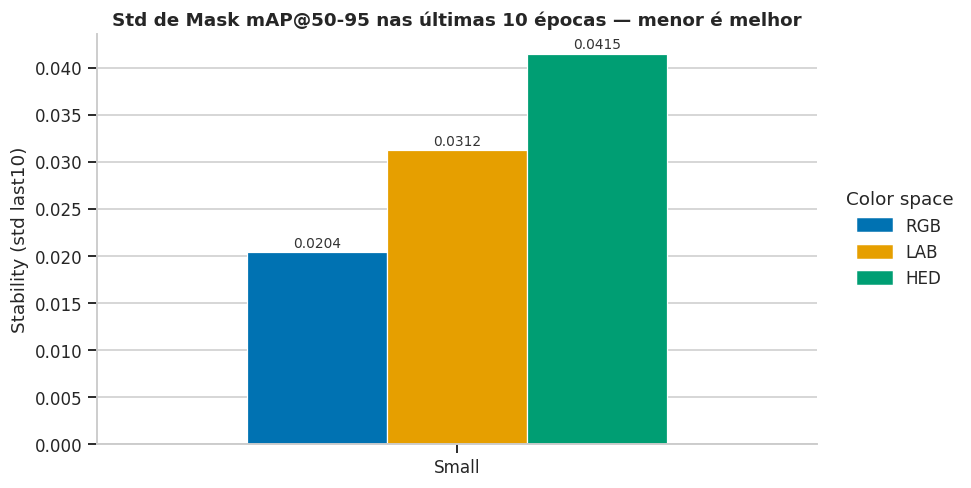

In [81]:
fig, ax = plt.subplots(figsize=(9, 4.6))
grouped_bar(ax, df_long, "Stability (std last10)",
            "Std de Mask mAP@50-95 nas últimas 10 épocas — menor é melhor", fmt="{:.4f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
ax.legend(handles=handles, title="Color space", loc="center left",
          bbox_to_anchor=(1.02, 0.5))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## 10. Velocidade de convergência

Em qual época cada run atingiu **95%** e **99%** do seu próprio best?
Convergência rápida em LAB pode indicar que o color space facilita a
otimização (mais sinal por iteração).


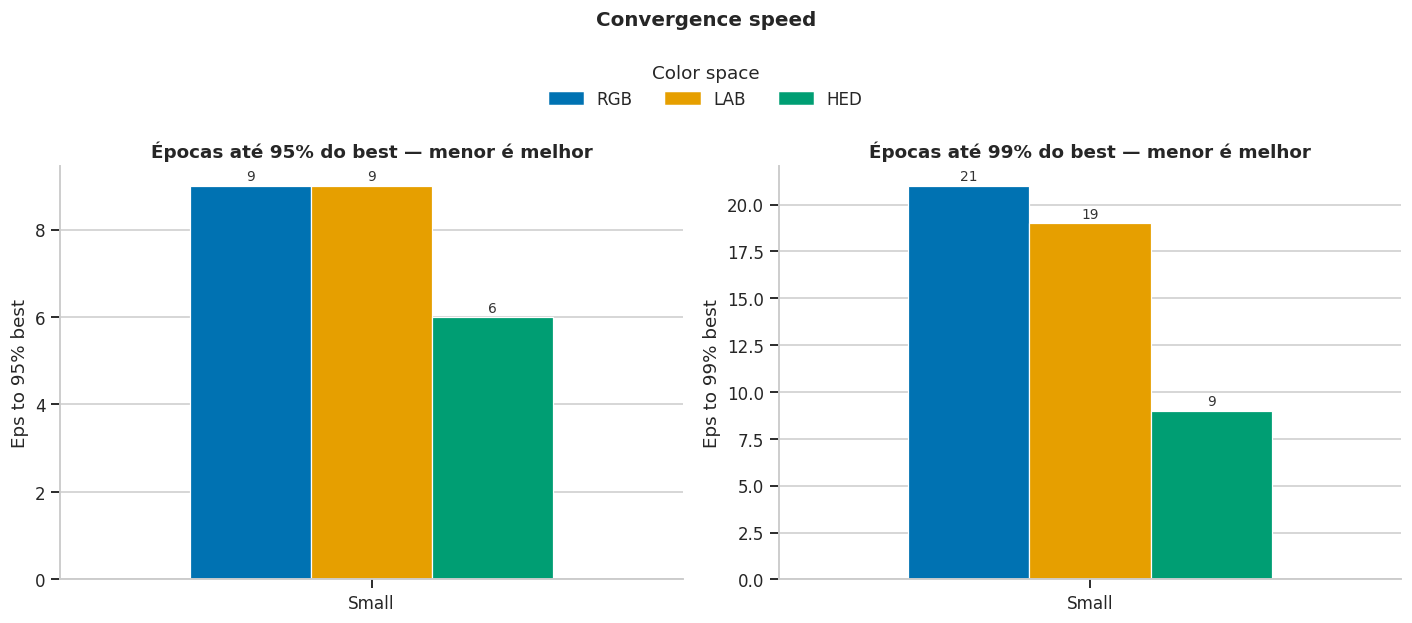

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
grouped_bar(axes[0], df_long, "Eps to 95% best", "Épocas até 95% do best — menor é melhor", fmt="{:.0f}")
grouped_bar(axes[1], df_long, "Eps to 99% best", "Épocas até 99% do best — menor é melhor", fmt="{:.0f}")

handles = [Patch(color=VERSION_PALETTE[v], label=v) for v in VERSION_ORDER]
fig.legend(handles=handles, title="Color space", loc="upper center",
           bbox_to_anchor=(0.5, 1.06), ncol=len(VERSION_ORDER))
fig.suptitle("Convergence speed", y=1.13, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Curvas de treino

`mAP@50-95(M)` ao longo das épocas, suavizado. Marker no best epoch.


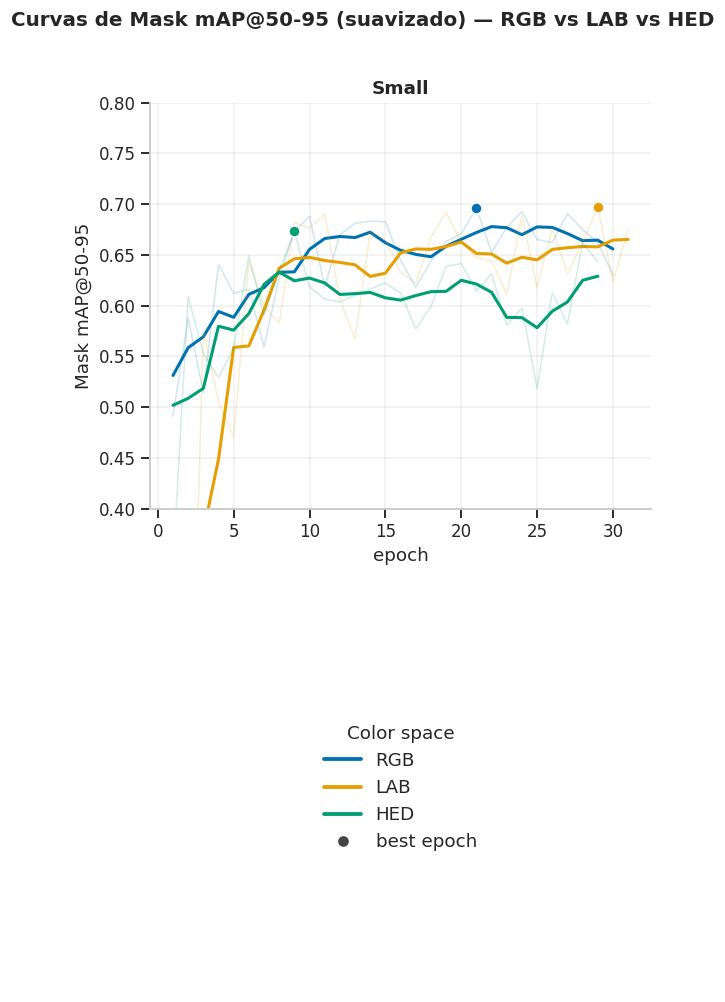

In [83]:
WINDOW = 5
n = len(MODEL_ORDER_PRESENT)
ncols = min(3, max(1, n))
nrows = int(np.ceil((n + 1) / ncols))  # +1 para legenda
fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, m in enumerate(MODEL_ORDER_PRESENT):
    ax = axes_flat[i]
    for v in VERSION_ORDER:
        sel = df_long[(df_long["Model"] == m) & (df_long["Version"] == v)]
        if sel.empty:
            continue
        df = sel.iloc[0]["_df"]
        if "metrics/mAP50-95(M)" not in df:
            continue
        eps = df["epoch"].to_numpy()
        y = df["metrics/mAP50-95(M)"].to_numpy()
        y_smooth = smooth(y, window=WINDOW)
        c = VERSION_PALETTE[v]
        ax.plot(eps, y, color=c, alpha=0.18, lw=1)
        ax.plot(eps, y_smooth, color=c, lw=2.0, label=v)
        best_idx = int(np.argmax(y))
        ax.scatter([eps[best_idx]], [y[best_idx]], color=c, s=55, zorder=5,
                   edgecolor="white", linewidth=1.2)
    ax.set_title(f"{m}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("Mask mAP@50-95")
    ax.set_ylim(0.4, 0.80)
    ax.grid(True, alpha=0.3)

# Esconde axes extras
for j in range(n, len(axes_flat) - 1):
    axes_flat[j].axis("off")

# Legenda no último axis
legend_ax = axes_flat[-1]
legend_ax.axis("off")
handles = [
    plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2.5, label=v)
    for v in VERSION_ORDER
]
handles.append(plt.Line2D([0], [0], marker="o", color="#444", markersize=8, lw=0,
                          markeredgecolor="white", label="best epoch"))
legend_ax.legend(handles=handles, loc="center", title="Color space", fontsize=12)

fig.suptitle("Curvas de Mask mAP@50-95 (suavizado) — " + " vs ".join(VERSION_ORDER),
             y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 12. Curvas de loss — `train` vs `val seg_loss`

Linha sólida = `train`, tracejada = `val`. Gap = sinal de overfit.


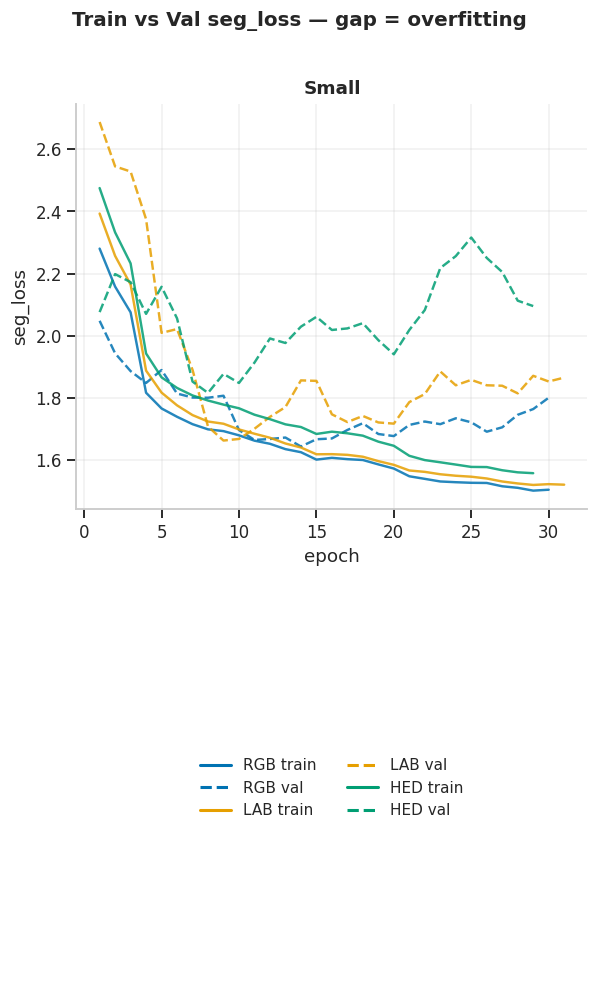

### Overfit gap no best ep (val − train seg_loss)

Version,RGB,LAB,HED
Model,,,
Small,+0.018,+0.105,-0.237


In [84]:
n = len(MODEL_ORDER_PRESENT)
ncols = min(3, max(1, n))
nrows = int(np.ceil((n + 1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, m in enumerate(MODEL_ORDER_PRESENT):
    ax = axes_flat[i]
    for v in VERSION_ORDER:
        sel = df_long[(df_long["Model"] == m) & (df_long["Version"] == v)]
        if sel.empty:
            continue
        df = sel.iloc[0]["_df"]
        if "train/seg_loss" not in df or "val/seg_loss" not in df:
            continue
        eps = df["epoch"].to_numpy()
        c = VERSION_PALETTE[v]
        ax.plot(eps, smooth(df["train/seg_loss"].to_numpy(), 5),
                color=c, lw=1.6, alpha=0.85, label=f"{v} train")
        ax.plot(eps, smooth(df["val/seg_loss"].to_numpy(), 5),
                color=c, lw=1.6, alpha=0.85, ls="--", label=f"{v} val")
    ax.set_title(f"{m}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("seg_loss")
    ax.grid(True, alpha=0.3)

for j in range(n, len(axes_flat) - 1):
    axes_flat[j].axis("off")
legend_ax = axes_flat[-1]
legend_ax.axis("off")
handles = []
for v in VERSION_ORDER:
    handles.append(plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2, label=f"{v} train"))
    handles.append(plt.Line2D([0], [0], color=VERSION_PALETTE[v], lw=2, ls="--", label=f"{v} val"))
legend_ax.legend(handles=handles, loc="center", ncol=2, fontsize=10)

fig.suptitle("Train vs Val seg_loss — gap = overfitting", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Tabela: gap absoluto val − train no best ep
display(Markdown("### Overfit gap no best ep (val − train seg_loss)"))
overfit_pivot = df_long.pivot(index="Model", columns="Version",
                               values="Overfit gap (seg)")[VERSION_ORDER].reindex(MODEL_ORDER_PRESENT)
display(overfit_pivot.style.format("{:+.3f}", na_rep="—").background_gradient(cmap="RdYlGn_r", axis=None))


## 13. LR efetivo (`lr/pg0` no meio do treino)

Mesma config, color spaces diferentes — espera-se LR praticamente
idêntico entre eles. Se houver diferença relevante, indica que o pipeline
de dados (ex: cache, dataloader, custo de leitura) está afetando o
regime de otimização.


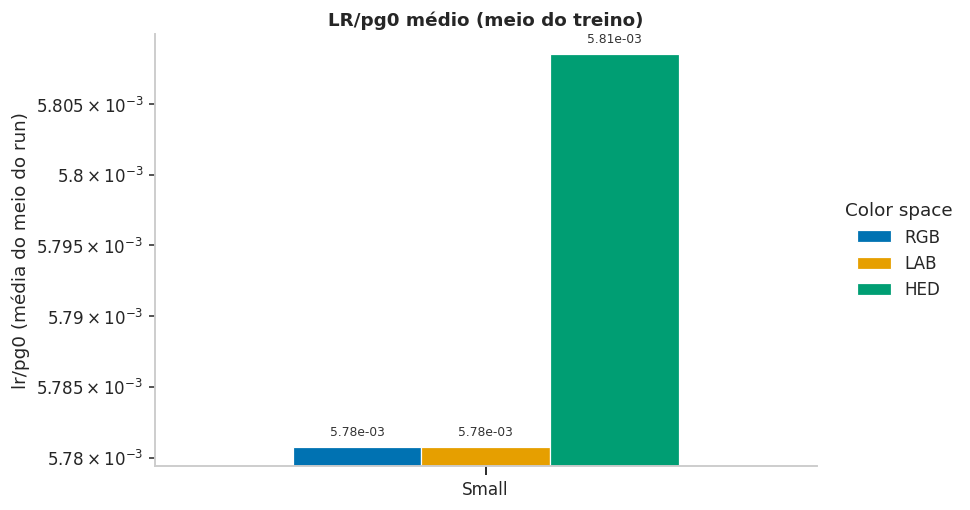

### LR diagnostics (start / mid / end)

In [85]:
lr_pivot = df_long.pivot(index="Model", columns="Version",
                          values="lr/pg0 mid")[VERSION_ORDER].reindex(MODEL_ORDER_PRESENT)

fig, ax = plt.subplots(figsize=(9, 4.8))
lr_pivot.plot(
    kind="bar", ax=ax, width=0.7,
    color=[VERSION_PALETTE[v] for v in VERSION_ORDER],
    edgecolor="white", linewidth=0.8,
)
ax.set_title("LR/pg0 médio (meio do treino)")
ax.set_xlabel("")
ax.set_ylabel("lr/pg0 (média do meio do run)")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Color space", loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(axis="x", visible=False)
add_value_labels(ax, fmt="{:.2e}", padding=0.02, fontsize=8)
plt.tight_layout()
plt.show()

display(Markdown("### LR diagnostics (start / mid / end)"))
display(
    df_long.pivot_table(index="Model", columns="Version",
                        values=["lr/pg0 start", "lr/pg0 mid", "lr/pg0 end"])
    .reindex(MODEL_ORDER_PRESENT).style.format("{:.2e}", na_rep="—")
)


## 14. Pareto: `mAP@50-95` vs `Train time`

Cada ponto = (color space, modelo). Letra = inicial do modelo.


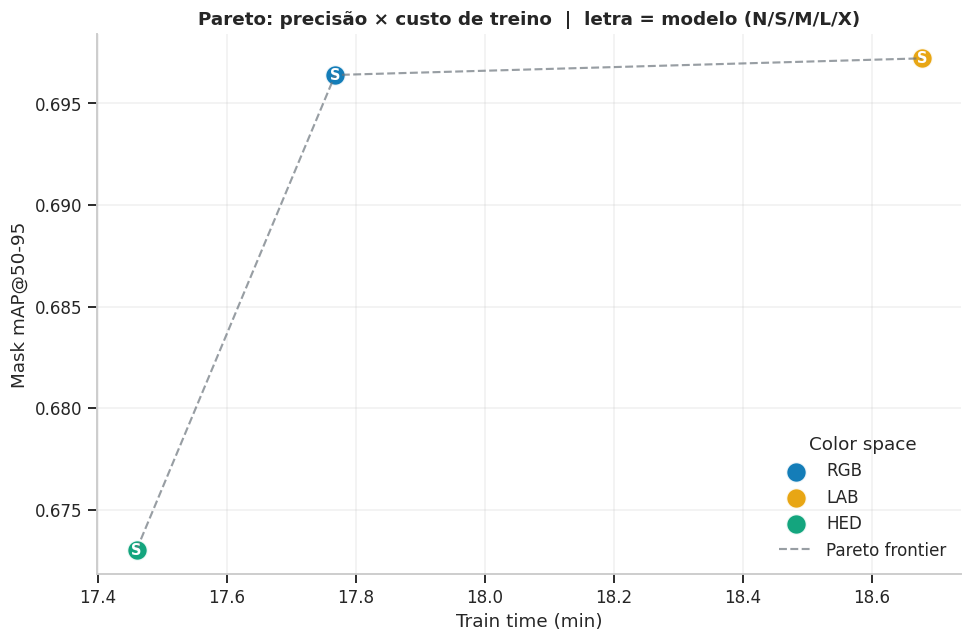

In [86]:
fig, ax = plt.subplots(figsize=(9, 6))

for v in VERSION_ORDER:
    sel = df_long[df_long["Version"] == v]
    if sel.empty:
        continue
    ax.scatter(
        sel["Train time (min)"], sel["Mask mAP@50-95"],
        s=180, color=VERSION_PALETTE[v], edgecolor="white", linewidth=1.4,
        label=v, alpha=0.92,
    )
    for _, r in sel.iterrows():
        label = "X" if r["Model"] == "XLarge" else r["Model"][:1]
        ax.annotate(
            label,
            (r["Train time (min)"], r["Mask mAP@50-95"]),
            ha="center", va="center", fontsize=9.5, color="white", fontweight="bold",
        )

# Pareto frontier
pf_pts = df_long.dropna(subset=["Train time (min)", "Mask mAP@50-95"]).copy()
pf_pts = pf_pts.sort_values("Train time (min)")
front = []
best_y = -np.inf
for _, r in pf_pts.iterrows():
    if r["Mask mAP@50-95"] > best_y:
        front.append((r["Train time (min)"], r["Mask mAP@50-95"]))
        best_y = r["Mask mAP@50-95"]
if len(front) >= 2:
    fx, fy = zip(*front)
    ax.plot(fx, fy, color=NEUTRAL, ls="--", lw=1.4, alpha=0.7, label="Pareto frontier")

ax.set_xlabel("Train time (min)")
ax.set_ylabel("Mask mAP@50-95")
ax.set_title("Pareto: precisão × custo de treino  |  letra = modelo (N/S/M/L/X)")
ax.legend(title="Color space", loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Diff de hiperparâmetros entre color spaces

A única variável esperada é o color_space upstream — todos os outros
hiperparâmetros devem ser idênticos entre runs (RGB / LAB / HED).
Use esta tabela para confirmar; células amareladas indicam divergência
de algum color space não-baseline em relação ao baseline (RGB).


In [87]:
hp_cols = ["optimizer", "lr0", "amp", "batch", "epochs (cfg)",
           "close_mosaic", "erasing", "weight_decay", "dropout"]

ref_model = "Small" if "Small" in MODEL_ORDER_PRESENT else MODEL_ORDER_PRESENT[0]
hp = (df_long[df_long["Model"] == ref_model][["Version"] + hp_cols]
      .drop_duplicates(subset=["Version"]).set_index("Version").reindex(VERSION_ORDER))


def style_diff(col: pd.Series):
    if col.dropna().empty:
        return ["" for _ in col]
    ref = col.dropna().iloc[0]
    return [
        "background-color: #FFF3CD" if (str(v) != str(ref)) else ""
        for v in col
    ]


display(Markdown(f"### Hiperparâmetros chave (run `{ref_model}` como referência)"))
display(hp.T.style.apply(style_diff, axis=1)
        .set_caption(f"Amarelo = color space difere de {BASELINE} (esperado: tudo igual)"))


### Hiperparâmetros chave (run `Small` como referência)

Version,RGB,LAB,HED
optimizer,MuSGD,MuSGD,MuSGD
lr0,0.002000,0.002000,0.002000
amp,True,True,True
batch,32,32,32
epochs (cfg),120,120,120
close_mosaic,15,15,15
erasing,0.000000,0.000000,0.000000
weight_decay,0.000500,0.000500,0.000500
dropout,0.000000,0.000000,0.000000


## 16. Heatmap geral — métricas × runs

Visão consolidada normalizada por linha. Mais escuro = melhor para essa
métrica. Métricas onde "menor é melhor" têm escala invertida.


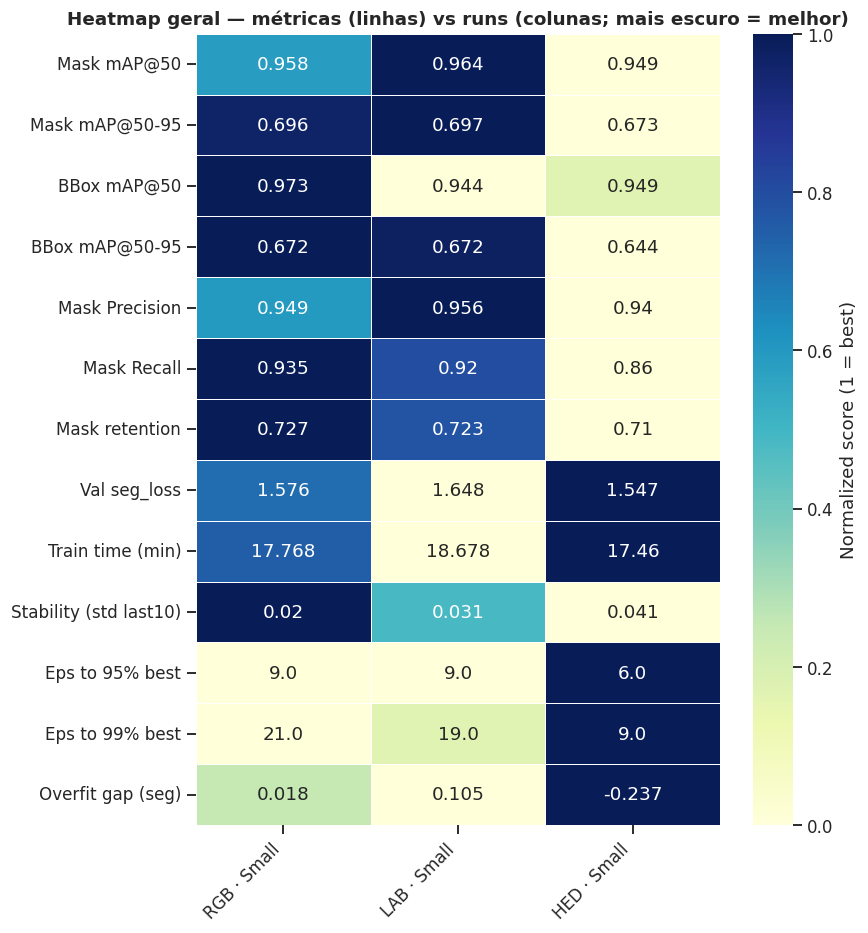

In [88]:
heat = df_long.copy()
heat["__col__"] = heat["Version"].astype(str) + " · " + heat["Model"].astype(str)
col_order = [f"{v} · {m}" for m in MODEL_ORDER_PRESENT for v in VERSION_ORDER]

higher_better_heat = ["Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
                       "Mask Precision", "Mask Recall", "Mask retention"]
lower_better_heat = ["Val seg_loss", "Train time (min)", "Stability (std last10)",
                      "Eps to 95% best", "Eps to 99% best", "Overfit gap (seg)"]

rows_data = {}
for met in higher_better_heat + lower_better_heat:
    if met not in heat:
        continue
    sub = heat.set_index("__col__")[met].reindex(col_order)
    rng = (sub.max() - sub.min()) + 1e-12
    if met in lower_better_heat:
        norm = (sub.max() - sub) / rng
    else:
        norm = (sub - sub.min()) / rng
    rows_data[met] = norm

heat_norm = pd.DataFrame(rows_data).T
heat_raw = heat.set_index("__col__")[higher_better_heat + lower_better_heat].T.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(col_order)), 0.55 * len(heat_norm) + 1.5))
sns.heatmap(
    heat_norm,
    annot=heat_raw.round(3), fmt="",
    cmap="YlGnBu", cbar_kws={"label": "Normalized score (1 = best)"},
    linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Heatmap geral — métricas (linhas) vs runs (colunas; mais escuro = melhor)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 17. Insights automáticos

In [89]:
insights = []

# 1. Champion absoluto
overall_champ = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
insights.append(
    f"**Champion absoluto**: `{overall_champ['Version']}` em `{overall_champ['Model']}` "
    f"com Mask mAP@50-95 = **{overall_champ['Mask mAP@50-95']:.4f}** "
    f"(best ep {overall_champ['Best epoch']})."
)

# 2. Δ vs RGB (uma comparação por color space não-baseline)
versions_present = list(df_long["Version"].unique())
if BASELINE in versions_present:
    pivot_ins = df_long.pivot(index="Model", columns="Version", values="Mask mAP@50-95")
    others_ins = [v for v in VERSION_ORDER if v != BASELINE and v in pivot_ins.columns]
    for v in others_ins:
        sub = pivot_ins.dropna(subset=[BASELINE, v])
        if sub.empty:
            continue
        wins   = int((sub[v] > sub[BASELINE]).sum())
        losses = int((sub[v] < sub[BASELINE]).sum())
        ties   = int(((sub[v] - sub[BASELINE]).abs() < 1e-4).sum())
        avg_delta = (sub[v] - sub[BASELINE]).mean()
        favored = (
            f"{v} favorecido" if avg_delta > 0
            else f"{BASELINE} favorecido" if avg_delta < 0
            else "empate"
        )
        insights.append(
            f"**{v} vs {BASELINE} (Mask mAP@50-95)**: {v} ganha em {wins} / {len(sub)} modelos, "
            f"{BASELINE} ganha em {losses}, empate em {ties}. "
            f"Δ médio = {avg_delta:+.4f} ({favored})."
        )

# 3. Melhor par color_space × modelo
best = df_long.loc[df_long["Mask mAP@50-95"].idxmax()]
insights.append(
    f"**Melhor combinação**: `{best['Version']} + {best['Model']}` "
    f"({best['Mask mAP@50-95']:.4f} mAP@50-95)."
)

# 4. Run mais estável
stab = df_long.dropna(subset=["Stability (std last10)"])
if not stab.empty:
    stable = stab.loc[stab["Stability (std last10)"].idxmin()]
    insights.append(
        f"**Run mais estável** (menor std nas últimas 10 ep): "
        f"`{stable['Version']}/{stable['Model']}` (σ = {stable['Stability (std last10)']:.4f})."
    )

# 5. Convergência mais rápida
conv = df_long.dropna(subset=["Eps to 95% best"])
if not conv.empty:
    fast = conv.loc[conv["Eps to 95% best"].idxmin()]
    insights.append(
        f"**Convergência mais rápida**: `{fast['Version']}/{fast['Model']}` "
        f"atingiu 95% do best em {int(fast['Eps to 95% best'])} épocas."
    )

# 6. Best efficiency (mAP / min)
df_long["Efficiency"] = df_long["Mask mAP@50-95"] / df_long["Train time (min)"]
eff = df_long.dropna(subset=["Efficiency"])
if not eff.empty:
    e = eff.loc[eff["Efficiency"].idxmax()]
    insights.append(
        f"**Mais eficiente** (mAP@50-95 por minuto): "
        f"`{e['Version']}/{e['Model']}` ({e['Efficiency']:.4f} mAP/min)."
    )

display(Markdown("### Destaques\n\n" + "\n\n".join(f"- {x}" for x in insights)))


### Destaques

- **Champion absoluto**: `LAB` em `Small` com Mask mAP@50-95 = **0.6972** (best ep 29).

- **LAB vs RGB (Mask mAP@50-95)**: LAB ganha em 1 / 1 modelos, RGB ganha em 0, empate em 0. Δ médio = +0.0008 (LAB favorecido).

- **HED vs RGB (Mask mAP@50-95)**: HED ganha em 0 / 1 modelos, RGB ganha em 1, empate em 0. Δ médio = -0.0234 (RGB favorecido).

- **Melhor combinação**: `LAB + Small` (0.6972 mAP@50-95).

- **Run mais estável** (menor std nas últimas 10 ep): `RGB/Small` (σ = 0.0204).

- **Convergência mais rápida**: `HED/Small` atingiu 95% do best em 6 épocas.

- **Mais eficiente** (mAP@50-95 por minuto): `RGB/Small` (0.0392 mAP/min).

## 18. Export — tabela completa para CSV

In [90]:
export_cols = [
    "Version", "Model",
    "Mask mAP@50", "Mask mAP@50-95", "BBox mAP@50", "BBox mAP@50-95",
    "Mask Precision", "Mask Recall", "Mask retention",
    "Val seg_loss", "Train seg_loss", "Overfit gap (seg)",
    "Best epoch", "Total epochs", "Train time (min)",
    "Eps to 95% best", "Eps to 99% best", "Stability (std last10)",
    "lr/pg0 start", "lr/pg0 mid", "lr/pg0 end",
    "optimizer", "lr0", "amp", "batch", "weight_decay", "dropout",
]
export = df_long[export_cols].copy()

out = BASE_DIR / "logs" / "compare_color_spaces_v7_summary.csv"
try:
    export.to_csv(out, index=False)
    print(f"Salvo: {out}")
except OSError as e:
    print(f"(sem permissão para salvar em {out}: {e})")

display(export.style.format(precision=4, na_rep="—"))


Salvo: /home/antoniovinicius/projects/sandbox_yolo26/logs/compare_color_spaces_v7_summary.csv


,Version,Model,Mask mAP@50,Mask mAP@50-95,BBox mAP@50,BBox mAP@50-95,Mask Precision,Mask Recall,Mask retention,Val seg_loss,Train seg_loss,Overfit gap (seg),Best epoch,Total epochs,Train time (min),Eps to 95% best,Eps to 99% best,Stability (std last10),lr/pg0 start,lr/pg0 mid,lr/pg0 end,optimizer,lr0,amp,batch,weight_decay,dropout
0,RGB,Small,0.9576,0.6964,0.9728,0.6723,0.9493,0.9353,0.7272,1.5760,1.5579,0.0181,21,30,17.7677,9,21,0.0204,0.0040,0.0058,0.0052,MuSGD,0.0020,True,32,0.0005,0.0000
1,LAB,Small,0.9639,0.6972,0.9436,0.6717,0.9559,0.9200,0.7233,1.6479,1.5433,0.1046,29,31,18.6783,9,19,0.0312,0.0040,0.0058,0.0052,MuSGD,0.0020,True,32,0.0005,0.0000
2,HED,Small,0.9485,0.6730,0.9485,0.6436,0.9395,0.8600,0.7095,1.5473,1.7841,-0.2368,9,29,17.4597,6,9,0.0415,0.0030,0.0058,0.0053,MuSGD,0.0020,True,32,0.0005,0.0000
